folder            : C:\Users\paraj\Documents\bayesian_die_swell-main\datas\infer-oldroyd-rom1\giesekus_lam_1_beta_0p5_alpha_0p2
curve file        : curve4_y.txt
U_avg             : 0.1
points            : 124 (thin=2)
x range           : [0, 5]
height range      : [1, 1.12]
max displacement  : 0.1202
sigma_noise prior : Exp(rate=83.18), mean 0.01202
sigma_bias prior  : Exp(mean=0.01202)
c_bias prior      : not inferred
l_bias prior      : Uniform(0.1, 5)
bias kernel       : squared_exp
bias anchor       : delta(0)=0
bias derivative   : delta'(5)=0
curve noise       : 1.0% of disp, sigma 0.001202 (realized 0.001147)
pressure          : [-0.7836] (no noise)


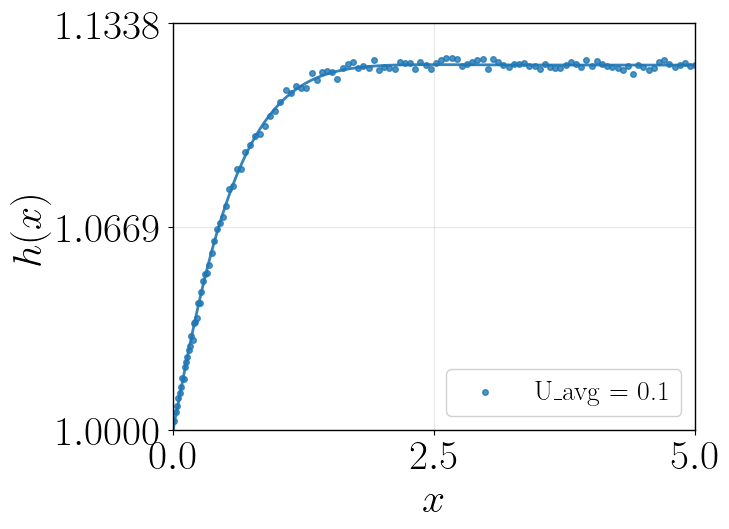

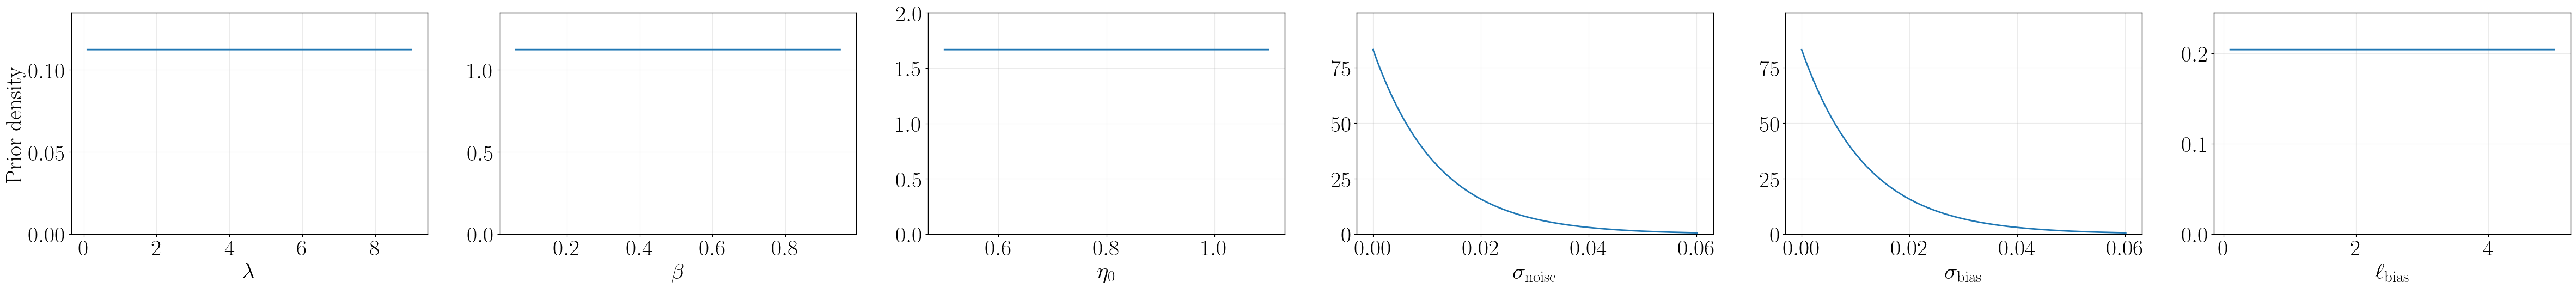

100%|██████████| 10000/10000 [01:32<00:00, 108.62it/s]


Parameter              Mean         Std      Rhat     95% CI Low    95% CI High
lambda           4.6513e-01  1.5072e-01     1.021     2.2492e-01     7.4744e-01
beta             3.1310e-01  9.1442e-02     1.016     1.1273e-01     5.3428e-01
eta_0            9.7547e-01  1.5007e-03     1.017     9.7240e-01     9.7843e-01
sigma_noise      1.1872e-03  8.0772e-05     1.015     1.0414e-03     1.3568e-03
sigma_bias       9.2156e-03  8.5903e-03     1.040     1.3289e-03     3.2458e-02
l_bias           3.1985e+00  1.0018e+00     1.018     1.4659e+00     4.9139e+00
N1 (oldroyd) = 0.0997321  tau_w = 0.390187  S_R = 0.1278  at rate 0.4


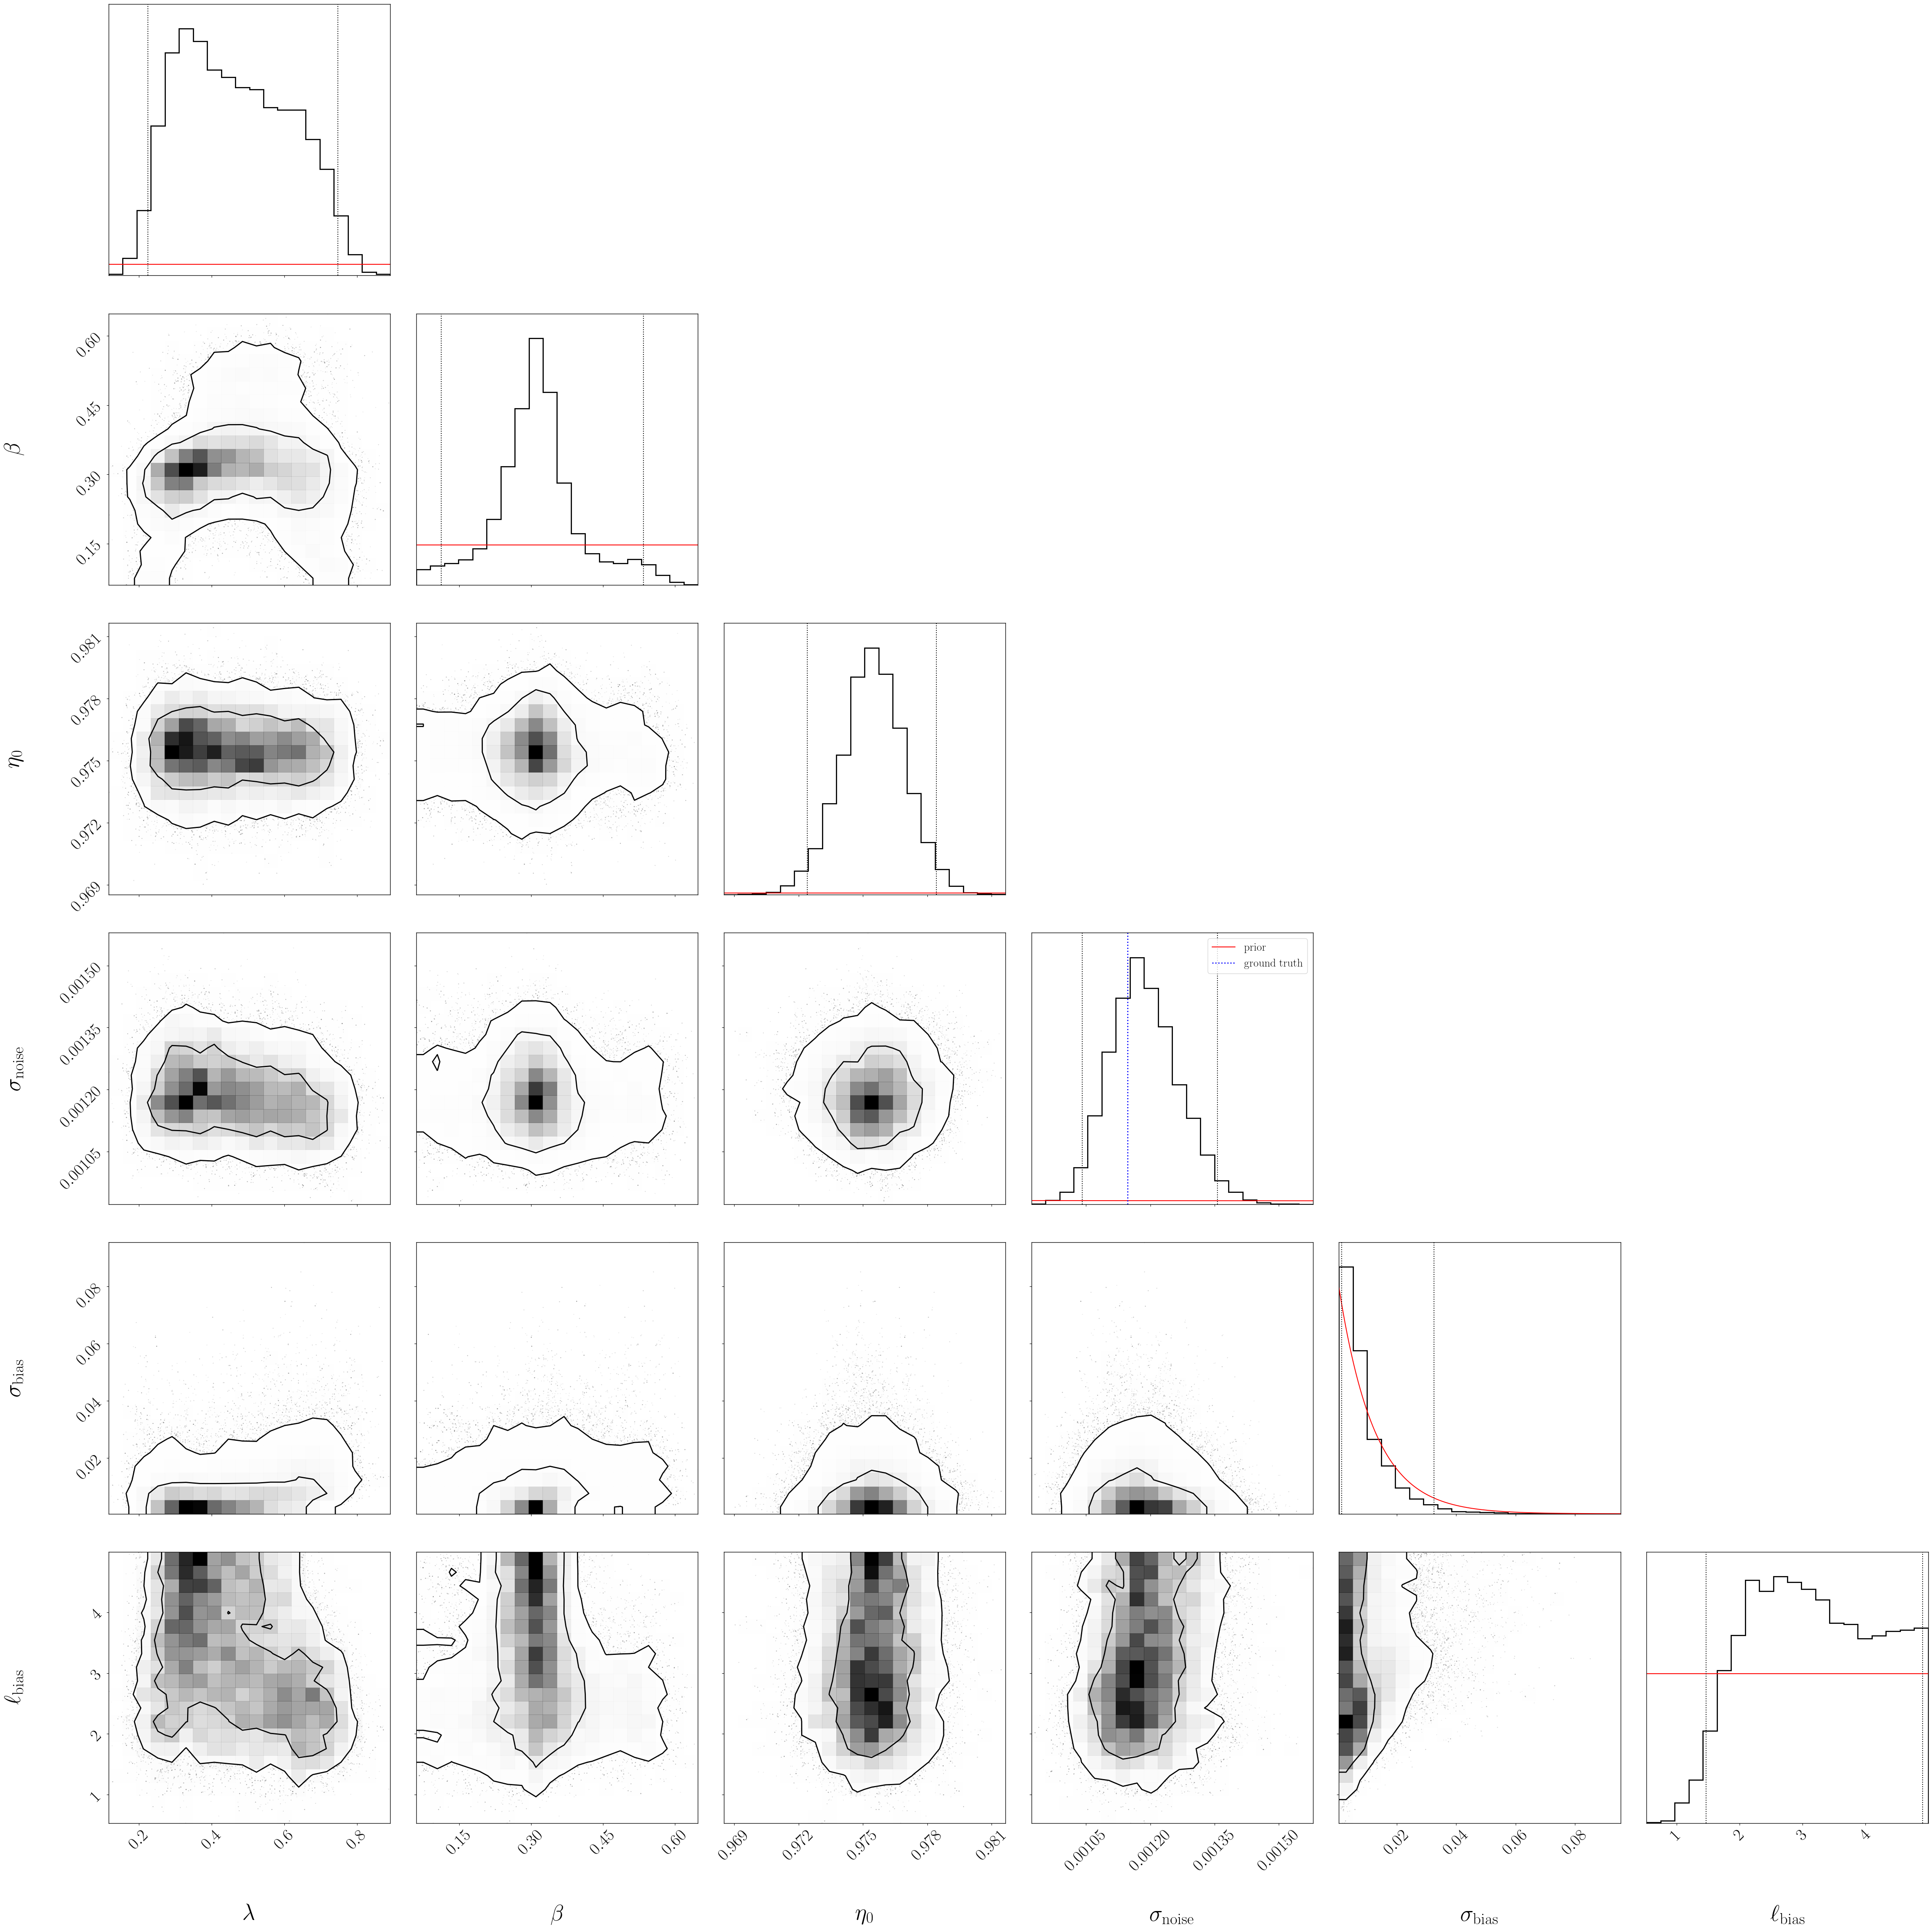


Posterior predictive (U=0.1, 95% band)
  coverage=99.2%  rms_z=0.59  max|z|=1.94  mean_z=-0.32


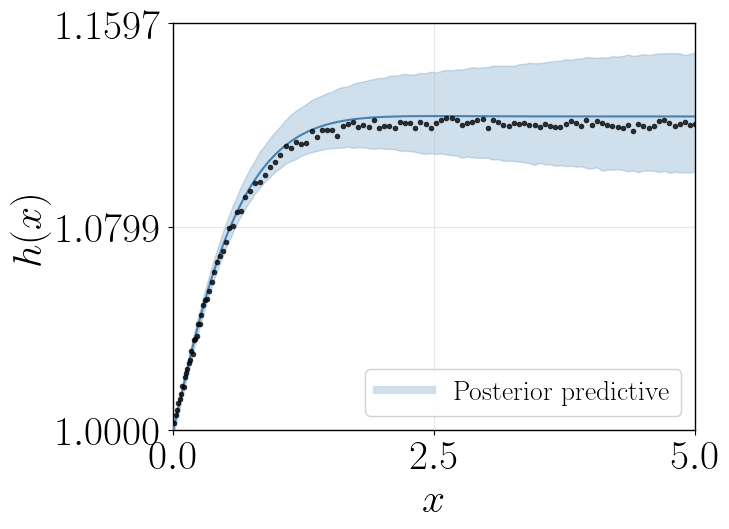


Pressure posterior predictive (95% band)
  coverage=100.0%  rms_z=0.06  max|z|=0.06  mean_z=0.06


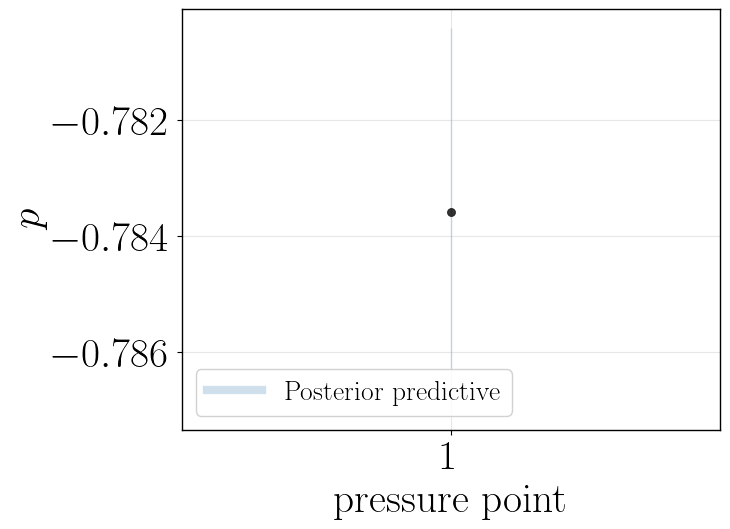

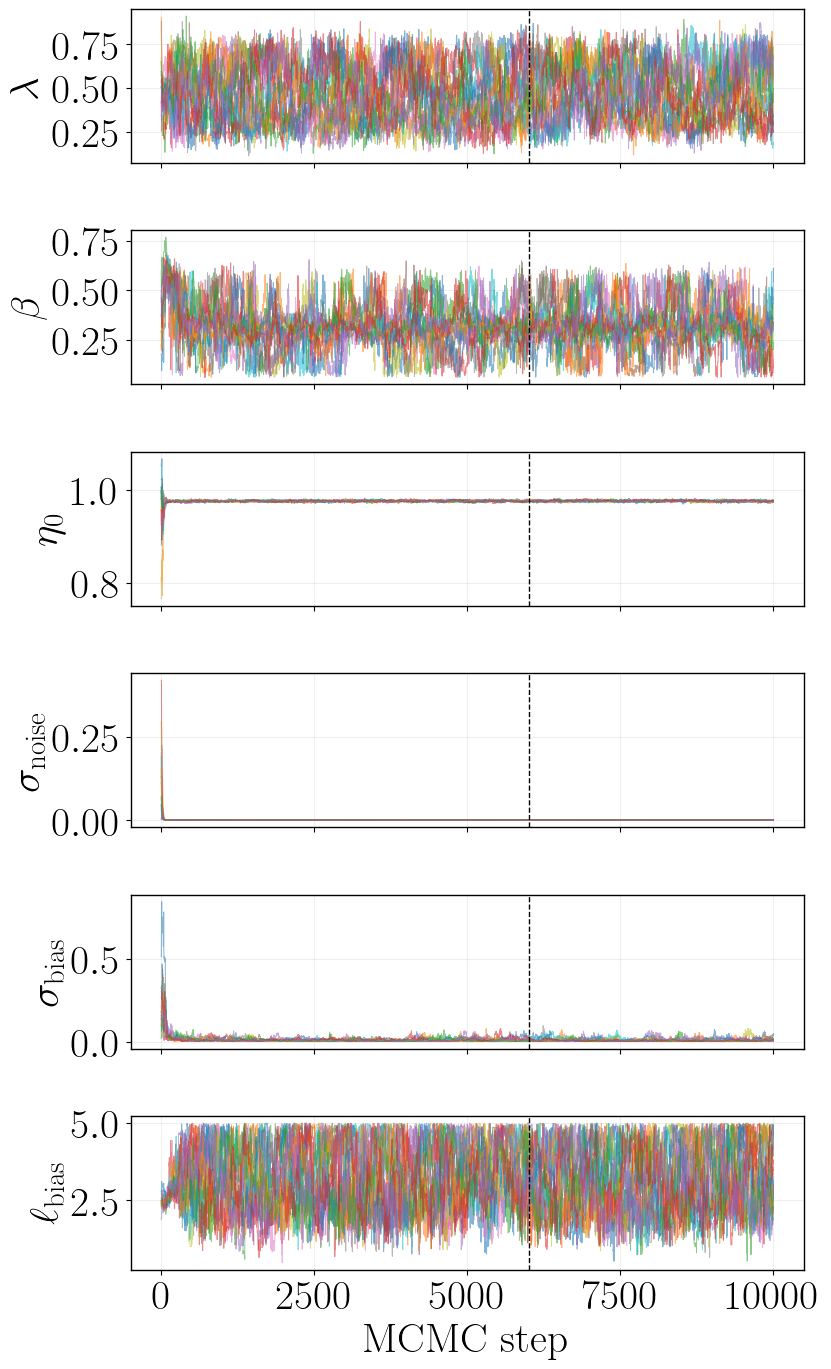

In [ ]:
import sys
import os
from pathlib import Path

CURRENT_DIR = os.getcwd()
FAXEN_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
sys.path.append(FAXEN_ROOT)
from packages import ROMCurve4BayesianInference

model = ROMCurve4BayesianInference(
    swell_root=Path(FAXEN_ROOT),
    model="oldroyd",
    mode="full_curve",       
    train_data_rels=["datas/oldroyd-rom1"],    
    filenames_train=("curve4_y_all.txt",  "parameters.txt"),  
    lambda_bounds = (0.1, 9.0),
    beta_bounds = (0.06, 0.95),
    eta0_bounds = (0.5, 1.1),
    pressure_filename="pressure_drop.txt",
    scaler="minmax",
    eps=1e-6,
    sigma_noise_percent=1.0,
    thin=2,
    sigma_bias="infer",
    l_bias = "infer",
    correlation_matrix= "squared_exp",
    constrained_model_error=True,
    use_pressure=True,
    augment_eta0=True,
    true_theta=None)

model.load_data(filename="datas/infer-oldroyd-rom1/giesekus_lam_5_beta_0p5_alpha_0p2/curve4_y.txt",
                u_avg_obs=0.1)

model.plot_data()
model.build_rom()
model.plot_prior()
model.run_mcmc(nwalkers=15, nsteps=10000, burn_fraction=0.5)
model.compute_N1()
model.plot_corner_all()
model.plot_posterior_predictive()
model.plot_trace_all()